In [1]:
# ═══════════════════════════════════════════════════════════════════
# DAY 3: K-MEANS CLUSTERING - IDENTIFYING LEARNER PROFILES
# CodeWorkout Fall 2019 - JY1 Project
# Following Lee et al. (2022) Methodology + Swanson et al. (2022)
# Date: April 14, 2024
# ═══════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════
# CELL 1: IMPORT LIBRARIES
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

 Libraries imported successfully!
NumPy version: 1.26.4
Pandas version: 2.2.2


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: LOAD FEATURE MATRIX
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("LOADING FEATURE MATRIX FROM DAY 2")
print("="*70)

# Load your feature matrix from Day 2
feature_matrix = pd.read_csv('feature_matrix.csv')

print(f"\n Feature matrix loaded!")
print(f"Dimensions: {feature_matrix.shape[0]} students × {feature_matrix.shape[1]} features")

# Display preview
print("\n Feature Matrix Preview:")
print(feature_matrix.head())

print(f"\n Available columns:")
print(list(feature_matrix.columns))



LOADING FEATURE MATRIX FROM DAY 2

 Feature matrix loaded!
Dimensions: 494 students × 19 features

 Feature Matrix Preview:
                                           SubjectID  problems_attempted  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...                  30   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...                  30   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...                  20   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...                  30   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...                  29   

   total_attempts  total_solved  completion_rate  avg_attempts  std_attempts  \
0             133            30            1.000      4.433333          6.99   
1             161            29            0.967      5.366667          6.20   
2              77            15            0.750      3.850000          3.36   
3             190            29            0.967      6.333333          9.00   
4             215 

In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3: PREPARE CLUSTERING FEATURES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("PREPARING FEATURES FOR CLUSTERING")
print("="*70)

# Select clustering features (exclude ID, min_attempts, and outcome)
clustering_features = [
    # Engagement (4)
    'problems_attempted', 'total_attempts', 'total_solved', 'completion_rate',
    # Retry/Persistence (4) - LEE'S KEY METRICS
    'avg_attempts', 'std_attempts', 'max_retries', 'proportion_reattempts',
    # Success (2)
    'success_rate', 'first_attempt_success_rate',
    # Error/Score (3)
    'avg_score', 'std_score', 'compile_error_rate',
    # Temporal (3)
    'active_days', 'avg_events_per_day', 'total_events'
]

print(f"\n📋 Using {len(clustering_features)} features for clustering:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i:2d}. {feat}")

# Extract clustering data
X = feature_matrix[clustering_features].copy()

print(f"\n Clustering dataset prepared: {X.shape}")
print(f"\n Feature statistics:")
print(X.describe().round(2))


PREPARING FEATURES FOR CLUSTERING

📋 Using 16 features for clustering:
   1. problems_attempted
   2. total_attempts
   3. total_solved
   4. completion_rate
   5. avg_attempts
   6. std_attempts
   7. max_retries
   8. proportion_reattempts
   9. success_rate
  10. first_attempt_success_rate
  11. avg_score
  12. std_score
  13. compile_error_rate
  14. active_days
  15. avg_events_per_day
  16. total_events

 Clustering dataset prepared: (494, 16)

 Feature statistics:
       problems_attempted  total_attempts  total_solved  completion_rate  \
count              494.00          494.00        494.00           494.00   
mean                28.98          165.61         27.21             0.94   
std                  3.02           97.23          4.47             0.11   
min                 10.00           11.00          0.00             0.00   
25%                 30.00           96.25         26.00             0.90   
50%                 30.00          150.00         29.00            

In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: FEATURE STANDARDIZATION (CRITICAL FOR K-MEANS!)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FEATURE STANDARDIZATION (Z-SCORE NORMALIZATION)")
print("="*70)

print("\nWhy standardization is critical for K-means:")
print("  - K-means uses Euclidean distance")
print("  - Features have different scales (e.g., total_attempts: 11-745)")
print("  - Without standardization, large-scale features dominate")
print("  - Standardization ensures equal contribution")

print("\n BEFORE Standardization (sample features):")
sample_features = ['total_attempts', 'completion_rate', 'avg_attempts']
print(X[sample_features].describe().round(2))

# Standardize features (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, 
                           index=feature_matrix.index)

print("\n AFTER Standardization (sample features):")
print(X_scaled_df[sample_features].describe().round(2))

print("\n Features standardized successfully!")
print("   - All features now have mean ≈ 0")
print("   - All features now have std ≈ 1")
print("   - Equal contribution to distance calculations")



FEATURE STANDARDIZATION (Z-SCORE NORMALIZATION)

Why standardization is critical for K-means:
  - K-means uses Euclidean distance
  - Features have different scales (e.g., total_attempts: 11-745)
  - Without standardization, large-scale features dominate
  - Standardization ensures equal contribution

 BEFORE Standardization (sample features):
       total_attempts  completion_rate  avg_attempts
count          494.00           494.00        494.00
mean           165.61             0.94          5.69
std             97.23             0.11          3.26
min             11.00             0.00          1.00
25%             96.25             0.90          3.37
50%            150.00             0.97          5.12
75%            210.00             1.00          7.32
max            745.00             1.00         24.83

 AFTER Standardization (sample features):
       total_attempts  completion_rate  avg_attempts
count          494.00           494.00        494.00
mean            -0.00      

In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5: DETERMINE OPTIMAL k - ELBOW METHOD
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FINDING OPTIMAL k - ELBOW METHOD (Swanson et al. 2022)")
print("="*70)

# Test k from 2 to 10 (following Swanson et al. 2022)
k_range = range(2, 11)
inertias = []

print("\nTesting k values from 2 to 10...")
print("(This may take 1-2 minutes...)\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  k={k}: Within-cluster sum of squares (WCSS) = {kmeans.inertia_:,.2f}")

print("\n Elbow method calculations complete!")

# Calculate percentage decrease in inertia
print("\n Percentage decrease in WCSS:")
for i in range(len(inertias)-1):
    decrease = ((inertias[i] - inertias[i+1]) / inertias[i]) * 100
    print(f"  k={k_range[i]} → k={k_range[i+1]}: {decrease:.2f}% decrease")


FINDING OPTIMAL k - ELBOW METHOD (Swanson et al. 2022)

Testing k values from 2 to 10...
(This may take 1-2 minutes...)

  k=2: Within-cluster sum of squares (WCSS) = 5,534.93
  k=3: Within-cluster sum of squares (WCSS) = 4,597.58
  k=4: Within-cluster sum of squares (WCSS) = 3,786.49
  k=5: Within-cluster sum of squares (WCSS) = 3,334.34
  k=6: Within-cluster sum of squares (WCSS) = 3,017.08
  k=7: Within-cluster sum of squares (WCSS) = 2,829.24
  k=8: Within-cluster sum of squares (WCSS) = 2,617.59
  k=9: Within-cluster sum of squares (WCSS) = 2,473.39
  k=10: Within-cluster sum of squares (WCSS) = 2,316.54

 Elbow method calculations complete!

 Percentage decrease in WCSS:
  k=2 → k=3: 16.94% decrease
  k=3 → k=4: 17.64% decrease
  k=4 → k=5: 11.94% decrease
  k=5 → k=6: 9.51% decrease
  k=6 → k=7: 6.23% decrease
  k=7 → k=8: 7.48% decrease
  k=8 → k=9: 5.51% decrease
  k=9 → k=10: 6.34% decrease


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6: DETERMINE OPTIMAL k - SILHOUETTE METHOD
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FINDING OPTIMAL k - SILHOUETTE METHOD (Swanson et al. 2022)")
print("="*70)

print("\nSilhouette Score Interpretation:")
print("  - Range: -1 to +1")
print("  - Values near +1: Well-separated clusters")
print("  - Values near 0: Overlapping clusters")
print("  - Values near -1: Misassigned samples")

silhouette_scores = []

print("\nCalculating silhouette scores...")
print("(This may take 1-2 minutes...)\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"  k={k}: Silhouette Score = {silhouette_avg:.4f}")

# Find optimal k
optimal_k_idx = silhouette_scores.index(max(silhouette_scores))
optimal_k = k_range[optimal_k_idx]
max_silhouette = max(silhouette_scores)

print(f"\n OPTIMAL k BY SILHOUETTE SCORE: {optimal_k}")
print(f"   Maximum silhouette score: {max_silhouette:.4f}")

print("\n Silhouette analysis complete!")


FINDING OPTIMAL k - SILHOUETTE METHOD (Swanson et al. 2022)

Silhouette Score Interpretation:
  - Range: -1 to +1
  - Values near +1: Well-separated clusters
  - Values near 0: Overlapping clusters
  - Values near -1: Misassigned samples

Calculating silhouette scores...
(This may take 1-2 minutes...)

  k=2: Silhouette Score = 0.2834
  k=3: Silhouette Score = 0.2601
  k=4: Silhouette Score = 0.2958
  k=5: Silhouette Score = 0.2367
  k=6: Silhouette Score = 0.2470
  k=7: Silhouette Score = 0.1972
  k=8: Silhouette Score = 0.2135
  k=9: Silhouette Score = 0.1929
  k=10: Silhouette Score = 0.2039

 OPTIMAL k BY SILHOUETTE SCORE: 4
   Maximum silhouette score: 0.2958

 Silhouette analysis complete!



 Saved: 10_elbow_silhouette_analysis.png


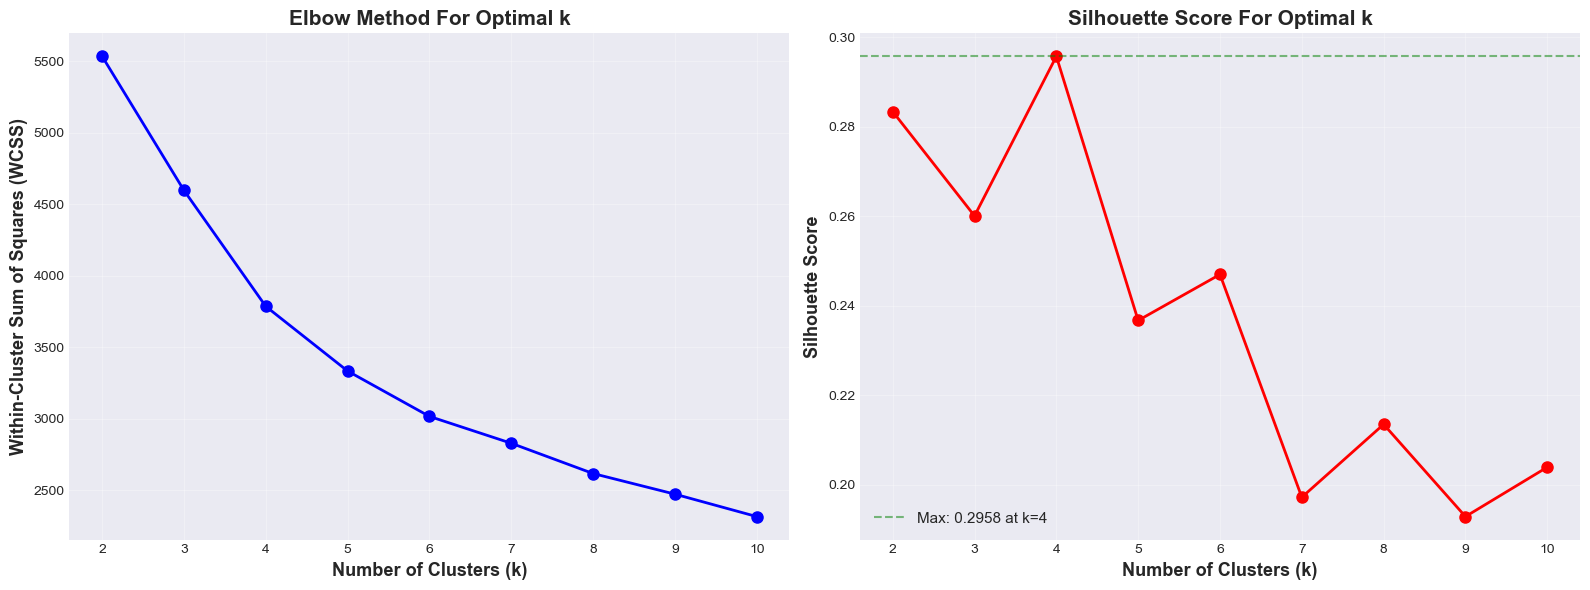

In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: VISUALIZE ELBOW PLOT
# ═══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=13, fontweight='bold')
ax1.set_title('Elbow Method For Optimal k', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Silhouette Plot
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=max_silhouette, color='g', linestyle='--', alpha=0.5,
            label=f'Max: {max_silhouette:.4f} at k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_title('Silhouette Score For Optimal k', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('10_elbow_silhouette_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: 10_elbow_silhouette_analysis.png")
plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: RUN FINAL K-MEANS WITH OPTIMAL k
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print(f"RUNNING FINAL K-MEANS CLUSTERING WITH k={optimal_k}")
print("="*70)

# Run final K-means with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to feature matrix
feature_matrix['Cluster'] = cluster_labels

print(f"\n K-means clustering complete!")
print(f"   Clusters identified: {optimal_k}")
print(f"   Silhouette score: {max_silhouette:.4f}")

# Cluster size distribution
print(f"\n Cluster Size Distribution:")
cluster_counts = feature_matrix['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(feature_matrix)) * 100
    print(f"   Cluster {cluster_id}: {count} students ({percentage:.1f}%)")


RUNNING FINAL K-MEANS CLUSTERING WITH k=4

 K-means clustering complete!
   Clusters identified: 4
   Silhouette score: 0.2958

 Cluster Size Distribution:
   Cluster 0: 36 students (7.3%)
   Cluster 1: 273 students (55.3%)
   Cluster 2: 82 students (16.6%)
   Cluster 3: 103 students (20.9%)


In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: CLUSTER PROFILING - DESCRIPTIVE STATISTICS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CLUSTER PROFILING - FOLLOWING LEE ET AL. (2022)")
print("="*70)

# Calculate cluster centroids (in original scale for interpretation)
cluster_profiles = feature_matrix.groupby('Cluster')[clustering_features].mean()

print("\n CLUSTER CENTROIDS (Original Scale):")
print(cluster_profiles.round(2))

# Key features for interpretation (Lee's focus)
key_features = ['avg_attempts', 'proportion_reattempts', 'success_rate', 
                'compile_error_rate', 'first_attempt_success_rate']

print("\n KEY FEATURES BY CLUSTER (Lee et al. 2022 focus):")
print(cluster_profiles[key_features].round(3))

# Add grades to profile
cluster_grades = feature_matrix.groupby('Cluster')['X-Grade'].agg(['mean', 'std', 'median'])
print("\n FINAL GRADES BY CLUSTER:")
print(cluster_grades.round(2))


CLUSTER PROFILING - FOLLOWING LEE ET AL. (2022)

 CLUSTER CENTROIDS (Original Scale):
         problems_attempted  total_attempts  total_solved  completion_rate  \
Cluster                                                                      
0                     24.08          139.89         15.61             0.66   
1                     29.65          148.44         28.49             0.96   
2                     28.54           56.50         28.18             0.99   
3                     29.28          306.97         27.09             0.92   

         avg_attempts  std_attempts  max_retries  proportion_reattempts  \
Cluster                                                                   
0                5.58          5.17        20.25                   0.79   
1                5.01          5.41        23.43                   0.78   
2                1.99          1.92         9.16                   0.44   
3               10.48         12.47        53.72                   0.

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: CLUSTER NAMING (INTERPRETING PROFILES)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CLUSTER INTERPRETATION & NAMING")
print("="*70)

# Create interpretation based on profiles
# You'll need to interpret based on YOUR actual results
# This is a template - adjust based on what you see

cluster_names = {}
cluster_descriptions = {}

print("\n CLUSTER PROFILES:")
for cluster_id in range(optimal_k):
    cluster_data = feature_matrix[feature_matrix['Cluster'] == cluster_id]
    
    avg_attempts = cluster_data['avg_attempts'].mean()
    success_rate = cluster_data['success_rate'].mean()
    grade = cluster_data['X-Grade'].mean()
    first_success = cluster_data['first_attempt_success_rate'].mean()
    proportion_retries = cluster_data['proportion_reattempts'].mean()
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} ({len(cluster_data)} students, {len(cluster_data)/len(feature_matrix)*100:.1f}%)")
    print(f"{'='*70}")
    print(f"  Average attempts per problem:     {avg_attempts:.2f}")
    print(f"  Proportion of reattempts:         {proportion_retries:.3f}")
    print(f"  Success rate (eventually solved): {success_rate:.3f}")
    print(f"  First attempt success rate:       {first_success:.3f}")
    print(f"  Average final grade:              {grade:.1f}%")
    
    # Suggest names based on characteristics
    # You'll need to customize these based on your actual results
    if avg_attempts < 4 and first_success > 0.4:
        cluster_names[cluster_id] = "Efficient Experts"
        cluster_descriptions[cluster_id] = "Low retries, high first-attempt success"
    elif avg_attempts > 8 and grade > 70:
        cluster_names[cluster_id] = "Persistent Improvers"
        cluster_descriptions[cluster_id] = "High retries but strong final performance"
    elif avg_attempts > 10 and grade < 50:
        cluster_names[cluster_id] = "Struggling Retriers"
        cluster_descriptions[cluster_id] = "Many retries, low performance"
    else:
        cluster_names[cluster_id] = f"Cluster {cluster_id}"
        cluster_descriptions[cluster_id] = "Moderate characteristics"

print("\n" + "="*70)
print("SUGGESTED CLUSTER NAMES:")
print("="*70)
for cluster_id in range(optimal_k):
    print(f"  Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print(f"    → {cluster_descriptions[cluster_id]}")


CLUSTER INTERPRETATION & NAMING

 CLUSTER PROFILES:

CLUSTER 0 (36 students, 7.3%)
  Average attempts per problem:     5.58
  Proportion of reattempts:         0.793
  Success rate (eventually solved): 0.659
  First attempt success rate:       0.225
  Average final grade:              63.4%

CLUSTER 1 (273 students, 55.3%)
  Average attempts per problem:     5.01
  Proportion of reattempts:         0.784
  Success rate (eventually solved): 0.961
  First attempt success rate:       0.291
  Average final grade:              63.1%

CLUSTER 2 (82 students, 16.6%)
  Average attempts per problem:     1.99
  Proportion of reattempts:         0.439
  Success rate (eventually solved): 0.987
  First attempt success rate:       0.671
  Average final grade:              54.6%

CLUSTER 3 (103 students, 20.9%)
  Average attempts per problem:     10.48
  Proportion of reattempts:         0.899
  Success rate (eventually solved): 0.924
  First attempt success rate:       0.151
  Average final grade: 

In [47]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: STATISTICAL VALIDATION - ANOVA
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STATISTICAL VALIDATION - ANOVA TESTS")
print("="*70)

print("\nResearch Question: Do clusters differ significantly in final grades?")
print("Null Hypothesis: All clusters have equal mean grades")
print("Alternative: At least one cluster has different mean grade\n")

# Prepare data for ANOVA
grade_groups = [feature_matrix[feature_matrix['Cluster'] == i]['X-Grade'].values 
                for i in range(optimal_k)]

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(*grade_groups)

print(f" ANOVA Results:")
print(f"   F-statistic: {f_statistic:.4f}")
print(f"   p-value: {p_value:.4e}")

if p_value < 0.001:
    print(f"    Result: HIGHLY SIGNIFICANT (p < 0.001)")
    print(f"    Clusters differ significantly in final grades!")
elif p_value < 0.05:
    print(f"    Result: SIGNIFICANT (p < 0.05)")
    print(f"    Clusters differ significantly in final grades!")
else:
    print(f"    Result: NOT SIGNIFICANT (p >= 0.05)")
    print(f"    No significant difference between clusters")

# Effect size (eta-squared)
# Calculate between-group and within-group variance
grand_mean = feature_matrix['X-Grade'].mean()
ss_between = sum([len(group) * (group.mean() - grand_mean)**2 for group in grade_groups])
ss_total = sum([(x - grand_mean)**2 for group in grade_groups for x in group])
eta_squared = ss_between / ss_total

print(f"\n Effect Size (Eta-squared):")
print(f"   η² = {eta_squared:.4f}")
if eta_squared < 0.01:
    print(f"    Small effect")
elif eta_squared < 0.06:
    print(f"    Medium effect")
else:
    print(f"    Large effect")


STATISTICAL VALIDATION - ANOVA TESTS

Research Question: Do clusters differ significantly in final grades?
Null Hypothesis: All clusters have equal mean grades
Alternative: At least one cluster has different mean grade

 ANOVA Results:
   F-statistic: 6.1599
   p-value: 4.0802e-04
    Result: HIGHLY SIGNIFICANT (p < 0.001)
    Clusters differ significantly in final grades!

 Effect Size (Eta-squared):
   η² = 0.0363
    Medium effect


In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: POST-HOC TESTS (PAIRWISE COMPARISONS)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("POST-HOC PAIRWISE COMPARISONS (Tukey HSD)")
print("="*70)

from scipy.stats import tukey_hsd

# Perform Tukey HSD test
res = tukey_hsd(*grade_groups)

print("\n Pairwise Comparisons (95% Confidence Intervals):")
print("\nMean Differences:")
for i in range(optimal_k):
    for j in range(i+1, optimal_k):
        cluster_i_name = cluster_names.get(i, f"Cluster {i}")
        cluster_j_name = cluster_names.get(j, f"Cluster {j}")
        
        mean_diff = grade_groups[i].mean() - grade_groups[j].mean()
        
        # Get confidence interval from Tukey HSD
        ci_lower = res.confidence_interval().low[i, j]
        ci_upper = res.confidence_interval().high[i, j]
        p_val = res.pvalue[i, j]
        
        sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        print(f"\n  {cluster_i_name} vs {cluster_j_name}:")
        print(f"    Mean difference: {mean_diff:.2f}")
        print(f"    95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
        print(f"    p-value: {p_val:.4f} {sig_marker}")

print("\n  Significance codes: *** p<0.001, ** p<0.01, * p<0.05")


POST-HOC PAIRWISE COMPARISONS (Tukey HSD)

 Pairwise Comparisons (95% Confidence Intervals):

Mean Differences:

  Cluster 0 vs Cluster 1:
    Mean difference: 0.27
    95% CI: [-7.70, 8.24]
    p-value: 0.9998 

  Cluster 0 vs Efficient Experts:
    Mean difference: 8.76
    95% CI: [-0.23, 17.74]
    p-value: 0.0593 

  Cluster 0 vs Cluster 3:
    Mean difference: -1.32
    95% CI: [-10.02, 7.38]
    p-value: 0.9796 

  Cluster 1 vs Efficient Experts:
    Mean difference: 8.49
    95% CI: [2.83, 14.15]
    p-value: 0.0007 ***

  Cluster 1 vs Cluster 3:
    Mean difference: -1.59
    95% CI: [-6.79, 3.61]
    p-value: 0.8598 

  Efficient Experts vs Cluster 3:
    Mean difference: -10.08
    95% CI: [-16.73, -3.43]
    p-value: 0.0006 ***

  Significance codes: *** p<0.001, ** p<0.01, * p<0.05



 Saved: 11_cluster_characteristics.png


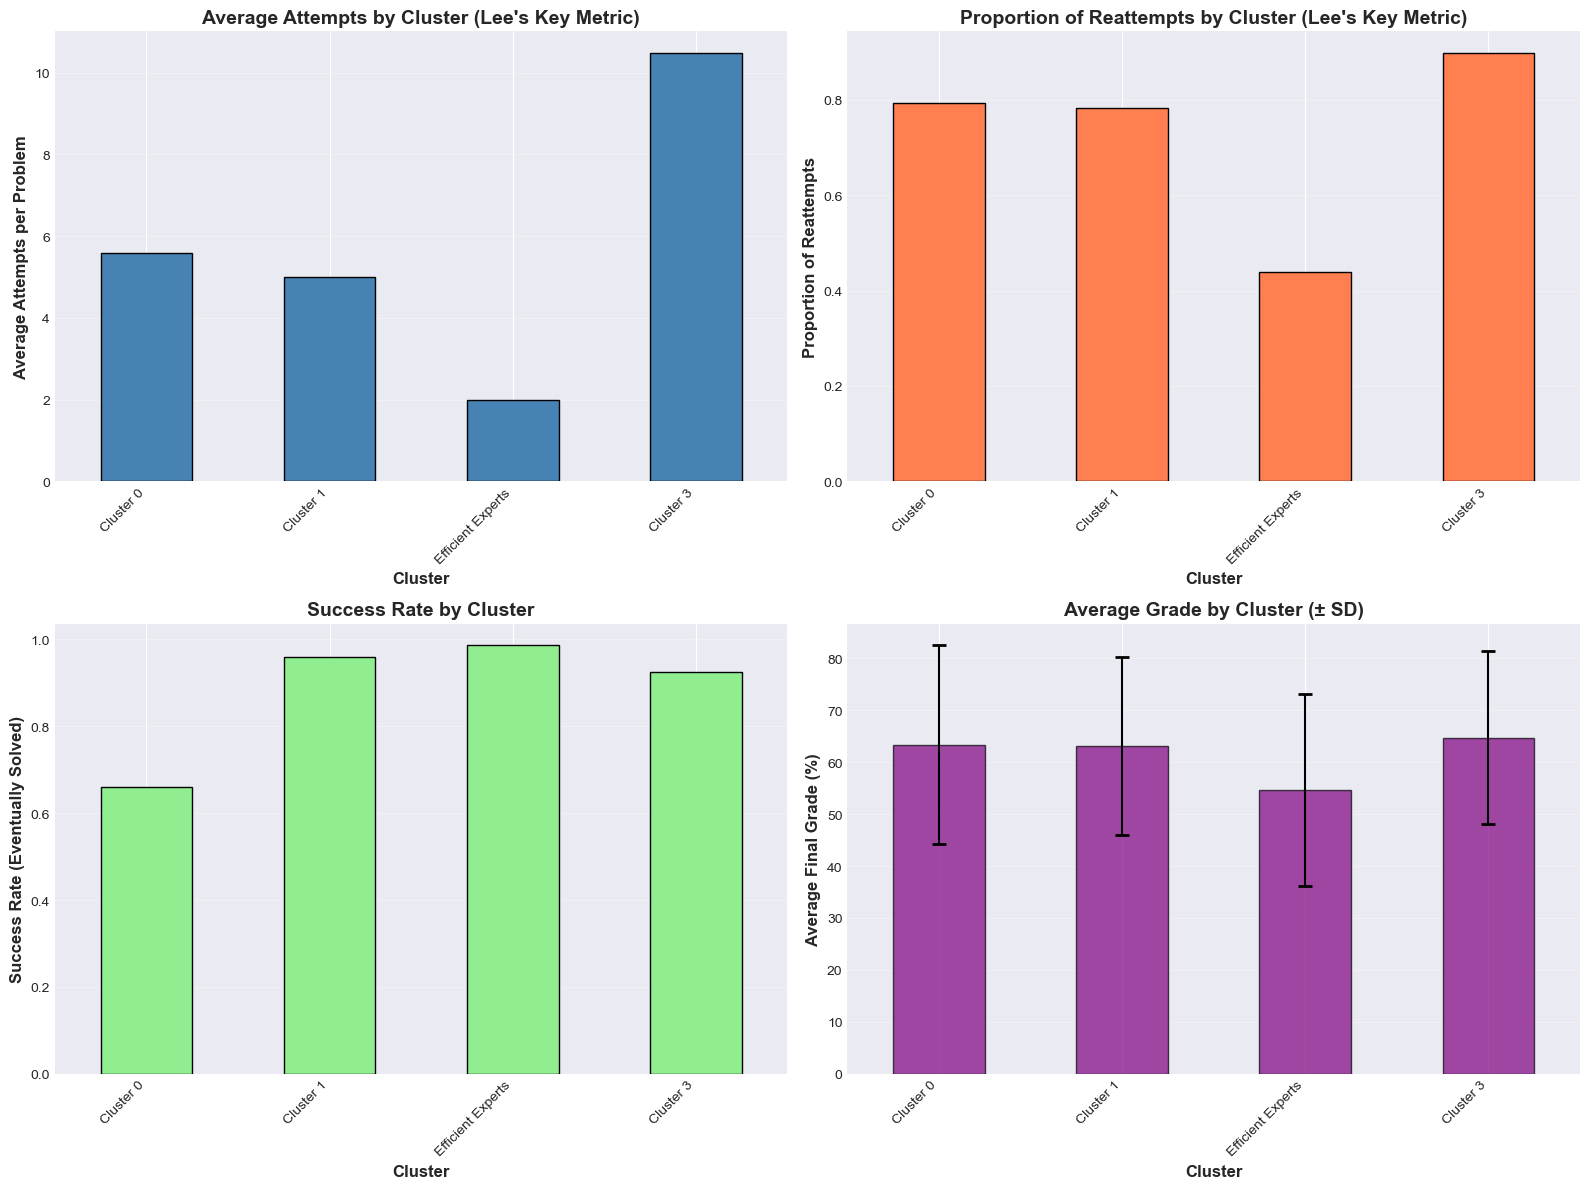

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: VISUALIZATION - CLUSTER CHARACTERISTICS
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average Attempts by Cluster
ax1 = axes[0, 0]
cluster_profiles['avg_attempts'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Attempts per Problem', fontsize=12, fontweight='bold')
ax1.set_title('Average Attempts by Cluster (Lee\'s Key Metric)', fontsize=14, fontweight='bold')
ax1.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)], rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Proportion of Reattempts by Cluster
ax2 = axes[0, 1]
cluster_profiles['proportion_reattempts'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax2.set_ylabel('Proportion of Reattempts', fontsize=12, fontweight='bold')
ax2.set_title('Proportion of Reattempts by Cluster (Lee\'s Key Metric)', fontsize=14, fontweight='bold')
ax2.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)], rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Success Rate by Cluster
ax3 = axes[1, 0]
cluster_profiles['success_rate'].plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Success Rate (Eventually Solved)', fontsize=12, fontweight='bold')
ax3.set_title('Success Rate by Cluster', fontsize=14, fontweight='bold')
ax3.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)], rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Average Grade by Cluster
ax4 = axes[1, 1]
cluster_grades['mean'].plot(kind='bar', ax=ax4, color='purple', edgecolor='black', alpha=0.7)
ax4.errorbar(range(optimal_k), cluster_grades['mean'], yerr=cluster_grades['std'],
             fmt='none', ecolor='black', capsize=5, capthick=2)
ax4.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Final Grade (%)', fontsize=12, fontweight='bold')
ax4.set_title('Average Grade by Cluster (± SD)', fontsize=14, fontweight='bold')
ax4.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)], rotation=45, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('11_cluster_characteristics.png', dpi=300, bbox_inches='tight')
print("\n Saved: 11_cluster_characteristics.png")
plt.show()



 Saved: 12_grade_distribution_by_cluster.png


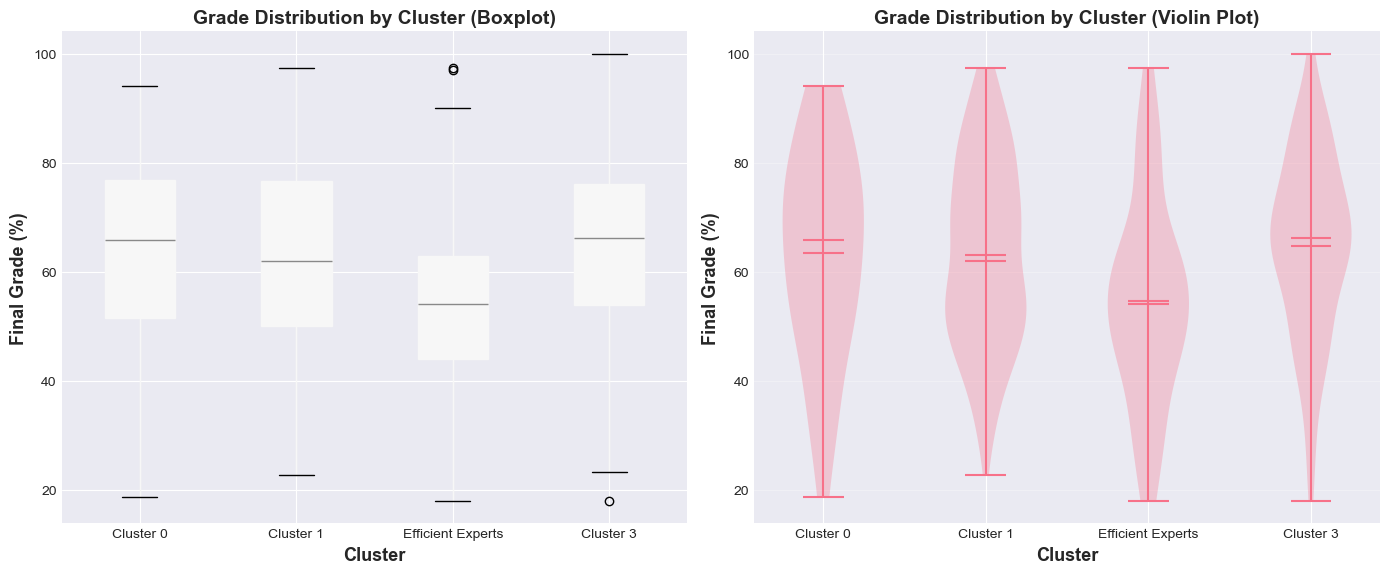

In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14: VISUALIZATION - GRADE DISTRIBUTION BY CLUSTER
# ═══════════════════════════════════════════════════════════════════

plt.figure(figsize=(14, 6))

# Box plot
ax = plt.subplot(1, 2, 1)
feature_matrix.boxplot(column='X-Grade', by='Cluster', ax=ax, patch_artist=True)
ax.set_xlabel('Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Final Grade (%)', fontsize=13, fontweight='bold')
ax.set_title('Grade Distribution by Cluster (Boxplot)', fontsize=14, fontweight='bold')
ax.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)])
plt.suptitle('')  # Remove automatic title

# Violin plot
ax2 = plt.subplot(1, 2, 2)
parts = ax2.violinplot([feature_matrix[feature_matrix['Cluster']==i]['X-Grade'].values 
                        for i in range(optimal_k)], 
                       positions=range(optimal_k), 
                       showmeans=True, showmedians=True)
ax2.set_xlabel('Cluster', fontsize=13, fontweight='bold')
ax2.set_ylabel('Final Grade (%)', fontsize=13, fontweight='bold')
ax2.set_title('Grade Distribution by Cluster (Violin Plot)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(optimal_k))
ax2.set_xticklabels([cluster_names.get(i, f"C{i}") for i in range(optimal_k)])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('12_grade_distribution_by_cluster.png', dpi=300, bbox_inches='tight')
print("\n Saved: 12_grade_distribution_by_cluster.png")
plt.show()


 Saved: 13_silhouette_plot.png


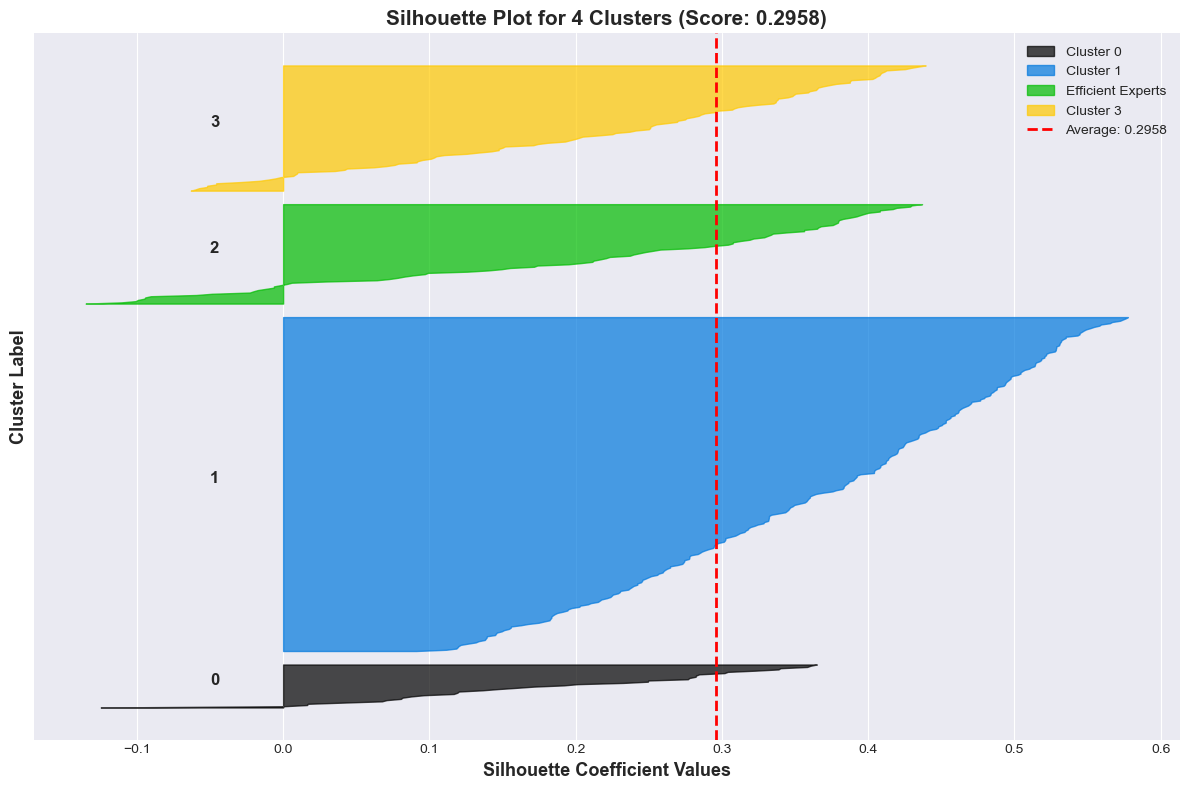

In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 15: VISUALIZATION - SILHOUETTE PLOT
# ═══════════════════════════════════════════════════════════════════

from matplotlib import cm

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

y_lower = 10
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)

for i in range(optimal_k):
    # Aggregate silhouette scores for samples belonging to cluster i
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7,
                     label=f'{cluster_names.get(i, f"Cluster {i}")}')
    
    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12, fontweight='bold')
    
    y_lower = y_upper + 10  # 10 for the 0 samples

ax.set_xlabel('Silhouette Coefficient Values', fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster Label', fontsize=13, fontweight='bold')
ax.set_title(f'Silhouette Plot for {optimal_k} Clusters (Score: {max_silhouette:.4f})', 
             fontsize=15, fontweight='bold')

# The vertical line for average silhouette score of all the values
ax.axvline(x=max_silhouette, color="red", linestyle="--", linewidth=2,
           label=f'Average: {max_silhouette:.4f}')
ax.set_yticks([])  # Clear the yaxis labels / ticks
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('13_silhouette_plot.png', dpi=300, bbox_inches='tight')
print("\n Saved: 13_silhouette_plot.png")
plt.show()


HIERARCHICAL CLUSTERING (VALIDATION METHOD)

Purpose: Validate K-means results with different clustering method
Method: Agglomerative hierarchical clustering with Ward linkage

 Saved: 14_hierarchical_dendrogram.png


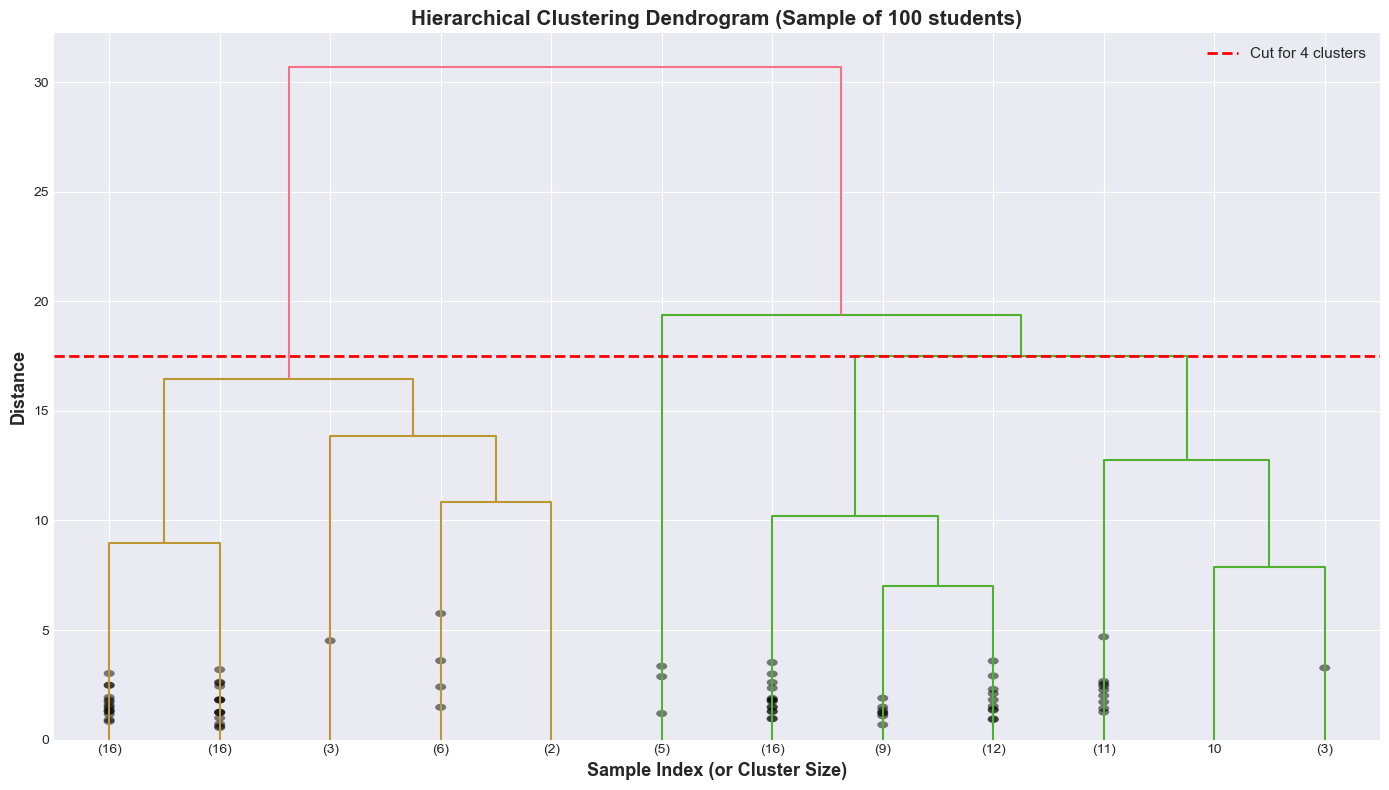


 Hierarchical clustering suggests 4 clusters is reasonable
   (based on dendrogram structure)


In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 16: HIERARCHICAL CLUSTERING (VALIDATION)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("HIERARCHICAL CLUSTERING (VALIDATION METHOD)")
print("="*70)

print("\nPurpose: Validate K-means results with different clustering method")
print("Method: Agglomerative hierarchical clustering with Ward linkage\n")

# Perform hierarchical clustering (using Ward linkage)
# Note: We'll use a sample for dendrogram visualization (all 494 students would be too crowded)
sample_size = min(100, len(X_scaled))  # Use up to 100 students for dendrogram
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=12, leaf_font_size=10,
           show_contracted=True)
plt.xlabel('Sample Index (or Cluster Size)', fontsize=13, fontweight='bold')
plt.ylabel('Distance', fontsize=13, fontweight='bold')
plt.title(f'Hierarchical Clustering Dendrogram (Sample of {sample_size} students)', 
          fontsize=15, fontweight='bold')
plt.axhline(y=linkage_matrix[-(optimal_k-1), 2], color='r', linestyle='--', linewidth=2,
            label=f'Cut for {optimal_k} clusters')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('14_hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
print(" Saved: 14_hierarchical_dendrogram.png")
plt.show()

print(f"\n Hierarchical clustering suggests {optimal_k} clusters is reasonable")
print("   (based on dendrogram structure)")


FEATURE IMPORTANCE ANALYSIS

 Top 10 Most Discriminative Features:
(Features with highest variance between cluster centers)

   1. total_events                  : 199649.8960
   2. total_attempts                : 10938.6962
   3. max_retries                   : 363.3297
   4. avg_events_per_day            : 44.2796
   5. total_solved                  : 38.2334
   6. std_attempts                  : 19.7859
   7. avg_attempts                  : 12.3695
   8. problems_attempted            : 6.6457
   9. active_days                   : 5.5127
  10. first_attempt_success_rate    : 0.0536

 Saved: 15_feature_importance.png


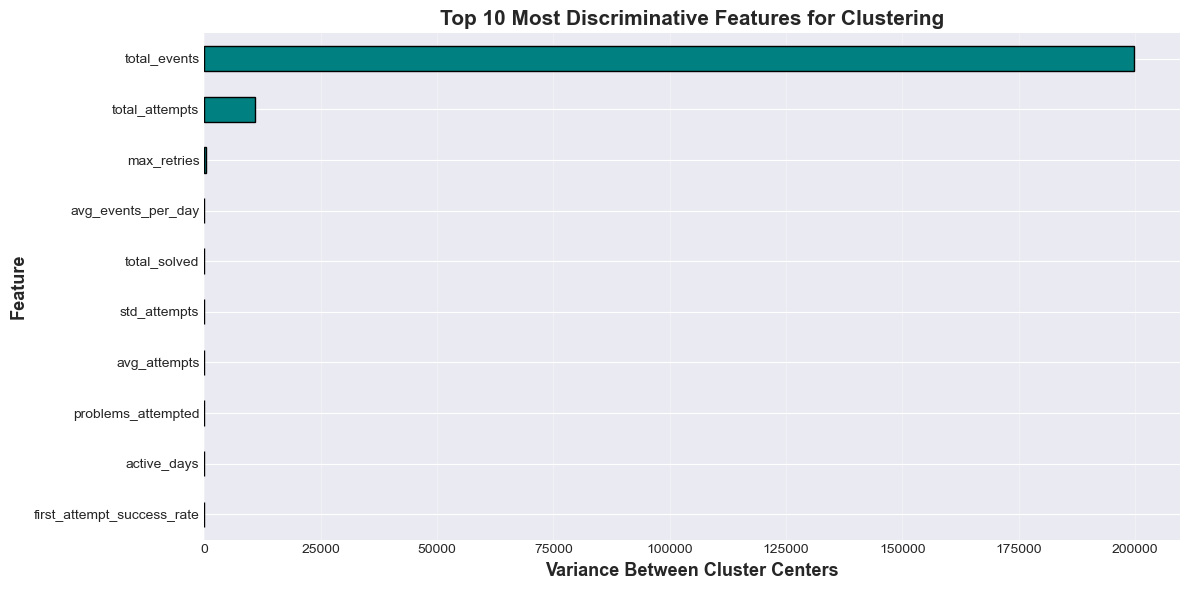

In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL 17: FEATURE IMPORTANCE FOR CLUSTERING
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Calculate variance between cluster centers for each feature
cluster_centers_original = feature_matrix.groupby('Cluster')[clustering_features].mean()
feature_variance = cluster_centers_original.var(axis=0).sort_values(ascending=False)

print("\n Top 10 Most Discriminative Features:")
print("(Features with highest variance between cluster centers)\n")

for i, (feature, variance) in enumerate(feature_variance.head(10).items(), 1):
    print(f"  {i:2d}. {feature:30s}: {variance:.4f}")

# Visualize top 10 features
plt.figure(figsize=(12, 6))
feature_variance.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Variance Between Cluster Centers', fontsize=13, fontweight='bold')
plt.ylabel('Feature', fontsize=13, fontweight='bold')
plt.title('Top 10 Most Discriminative Features for Clustering', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('15_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n Saved: 15_feature_importance.png")
plt.show()

In [18]:
# ═══════════════════════════════════════════════════════════════════
# CELL 18: CORRELATION: CLUSTER VS GRADE
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CORRELATION ANALYSIS: CLUSTER MEMBERSHIP VS FINAL GRADE")
print("="*70)

# Calculate point-biserial correlation for each cluster
from scipy.stats import pointbiserialr

print("\n Point-Biserial Correlations:")
print("(Correlation between being in a cluster and final grade)\n")

for cluster_id in range(optimal_k):
    # Create binary variable (1 if in cluster, 0 otherwise)
    in_cluster = (feature_matrix['Cluster'] == cluster_id).astype(int)
    
    # Calculate correlation
    correlation, p_value = pointbiserialr(in_cluster, feature_matrix['X-Grade'])
    
    sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    
    print(f"  {cluster_names.get(cluster_id, f'Cluster {cluster_id}'):25s}: r = {correlation:6.3f}, p = {p_value:.4f} {sig_marker}")

print("\n  Significance codes: *** p<0.001, ** p<0.01, * p<0.05")


CORRELATION ANALYSIS: CLUSTER MEMBERSHIP VS FINAL GRADE

 Point-Biserial Correlations:
(Correlation between being in a cluster and final grade)

  Cluster 0                : r =  0.021, p = 0.6413 
  Cluster 1                : r =  0.066, p = 0.1401 
  Efficient Experts        : r = -0.187, p = 0.0000 ***
  Cluster 3                : r =  0.077, p = 0.0881 

  Significance codes: *** p<0.001, ** p<0.01, * p<0.05


In [19]:
# ═══════════════════════════════════════════════════════════════════
# CELL 19: SAVE CLUSTERING RESULTS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("SAVING CLUSTERING RESULTS")
print("="*70)

# Save feature matrix with cluster assignments
feature_matrix.to_csv('feature_matrix_with_clusters.csv', index=False, encoding='utf-8')
print(" Saved: feature_matrix_with_clusters.csv")

# Save cluster profiles
cluster_profiles_with_grades = pd.concat([cluster_profiles, cluster_grades], axis=1)
cluster_profiles_with_grades.to_csv('cluster_profiles.csv', encoding='utf-8')
print(" Saved: cluster_profiles.csv")

# Save cluster names and descriptions
cluster_info = pd.DataFrame({
    'Cluster_ID': range(optimal_k),
    'Cluster_Name': [cluster_names.get(i, f"Cluster {i}") for i in range(optimal_k)],
    'Description': [cluster_descriptions.get(i, "") for i in range(optimal_k)],
    'Size': [len(feature_matrix[feature_matrix['Cluster']==i]) for i in range(optimal_k)],
    'Percentage': [(len(feature_matrix[feature_matrix['Cluster']==i])/len(feature_matrix)*100) 
                   for i in range(optimal_k)]
})
cluster_info.to_csv('cluster_information.csv', index=False, encoding='utf-8')
print(" Saved: cluster_information.csv")



SAVING CLUSTERING RESULTS
 Saved: feature_matrix_with_clusters.csv
 Saved: cluster_profiles.csv
 Saved: cluster_information.csv


In [20]:
# ═══════════════════════════════════════════════════════════════════
# CELL 20: COMPREHENSIVE SUMMARY REPORT
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("GENERATING CLUSTERING SUMMARY REPORT")
print("="*70)

# Save comprehensive summary
with open('Clustering_Summary_Report.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("K-MEANS CLUSTERING ANALYSIS SUMMARY\n")
    f.write("CodeWorkout Fall 2019 - Following Lee et al. (2022)\n")
    f.write("Date: April 14, 2024\n")
    f.write("="*70 + "\n\n")
    
    f.write("1. CLUSTERING CONFIGURATION:\n")
    f.write(f"   - Method: K-means clustering\n")
    f.write(f"   - Number of clusters (k): {optimal_k}\n")
    f.write(f"   - Features used: {len(clustering_features)}\n")
    f.write(f"   - Students clustered: {len(feature_matrix)}\n")
    f.write(f"   - Standardization: Z-score normalization\n")
    f.write(f"   - Random seed: 42 (for reproducibility)\n\n")
    
    f.write("2. CLUSTER QUALITY METRICS:\n")
    f.write(f"   - Silhouette score: {max_silhouette:.4f}\n")
    f.write(f"   - Within-cluster sum of squares: {inertias[optimal_k-2]:,.2f}\n")
    f.write(f"   - Quality: ")
    if max_silhouette > 0.7:
        f.write("Excellent\n\n")
    elif max_silhouette > 0.5:
        f.write("Good\n\n")
    elif max_silhouette > 0.3:
        f.write("Fair\n\n")
    else:
        f.write("Poor (overlapping clusters)\n\n")
    
    f.write("3. CLUSTER DISTRIBUTION:\n")
    for cluster_id in range(optimal_k):
        count = len(feature_matrix[feature_matrix['Cluster']==cluster_id])
        pct = (count / len(feature_matrix)) * 100
        f.write(f"   Cluster {cluster_id} ({cluster_names.get(cluster_id, f'C{cluster_id}')}): ")
        f.write(f"{count} students ({pct:.1f}%)\n")
    f.write("\n")
    
    f.write("4. STATISTICAL VALIDATION (ANOVA):\n")
    f.write(f"   - F-statistic: {f_statistic:.4f}\n")
    f.write(f"   - p-value: {p_value:.4e}\n")
    f.write(f"   - Effect size (eta-squared): {eta_squared:.4f}\n")
    f.write(f"   - Result: ")
    if p_value < 0.001:
        f.write("Clusters differ HIGHLY significantly in grades (p < 0.001)\n\n")
    elif p_value < 0.05:
        f.write("Clusters differ significantly in grades (p < 0.05)\n\n")
    else:
        f.write("No significant difference (p >= 0.05)\n\n")
    
    f.write("5. CLUSTER PROFILES:\n\n")
    for cluster_id in range(optimal_k):
        cluster_data = feature_matrix[feature_matrix['Cluster'] == cluster_id]
        f.write(f"   {cluster_names.get(cluster_id, f'Cluster {cluster_id}').upper()}:\n")
        f.write(f"   {'-'*60}\n")
        f.write(f"   Size: {len(cluster_data)} students ({len(cluster_data)/len(feature_matrix)*100:.1f}%)\n")
        f.write(f"   Description: {cluster_descriptions.get(cluster_id, 'N/A')}\n\n")
        f.write(f"   Key Characteristics:\n")
        f.write(f"     - Avg attempts per problem:      {cluster_data['avg_attempts'].mean():.2f}\n")
        f.write(f"     - Proportion of reattempts:      {cluster_data['proportion_reattempts'].mean():.3f}\n")
        f.write(f"     - Success rate:                  {cluster_data['success_rate'].mean():.3f}\n")
        f.write(f"     - First attempt success:         {cluster_data['first_attempt_success_rate'].mean():.3f}\n")
        f.write(f"     - Compile error rate:            {cluster_data['compile_error_rate'].mean():.3f}\n")
        f.write(f"     - Average final grade:           {cluster_data['X-Grade'].mean():.1f}% (SD={cluster_data['X-Grade'].std():.1f})\n")
        f.write(f"\n")
    
    f.write("6. TOP DISCRIMINATIVE FEATURES:\n")
    for i, (feature, variance) in enumerate(feature_variance.head(5).items(), 1):
        f.write(f"   {i}. {feature}: {variance:.4f}\n")
    f.write("\n")
    
    f.write("7. COMPARISON WITH LEE ET AL. (2022):\n")
    f.write(f"   - Lee found k=3 clusters in math learning\n")
    f.write(f"   - We found k={optimal_k} clusters in programming learning\n")
    f.write(f"   - Lee's 'slow-steady' learners had high retries + high grades\n")
    f.write(f"   - Check if we observe similar patterns in our clusters\n\n")
    
    f.write("8. FILES GENERATED:\n")
    f.write("   - 10_elbow_silhouette_analysis.png\n")
    f.write("   - 11_cluster_characteristics.png\n")
    f.write("   - 12_grade_distribution_by_cluster.png\n")
    f.write("   - 13_silhouette_plot.png\n")
    f.write("   - 14_hierarchical_dendrogram.png\n")
    f.write("   - 15_feature_importance.png\n")
    f.write("   - feature_matrix_with_clusters.csv\n")
    f.write("   - cluster_profiles.csv\n")
    f.write("   - cluster_information.csv\n\n")
    
    f.write("9. NEXT STEPS:\n")
    f.write("   - Day 4: Temporal analysis (cluster transitions)\n")
    f.write("   - Day 5-7: Predictive modeling\n")
    f.write("   - Week 4: Write dissertation\n\n")
    
    f.write("="*70 + "\n")
    f.write("END OF CLUSTERING ANALYSIS\n")
    f.write("="*70 + "\n")

print(" Saved: Clustering_Summary_Report.txt")


GENERATING CLUSTERING SUMMARY REPORT
 Saved: Clustering_Summary_Report.txt


In [21]:
# ═══════════════════════════════════════════════════════════════════
# CELL 21: FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════

print("\n ACCOMPLISHMENTS:")
print(f"   Determined optimal k: {optimal_k} clusters")
print(f"   Silhouette score: {max_silhouette:.4f}")
print(f"   Cluster profiling complete")
print(f"   tatistical validation: ANOVA F={f_statistic:.2f}, p={p_value:.4e}")
print(f"   {optimal_k} clusters identified and named")

print("\n CLUSTER SUMMARY:")
for cluster_id in range(optimal_k):
    count = len(feature_matrix[feature_matrix['Cluster']==cluster_id])
    pct = (count / len(feature_matrix)) * 100
    avg_grade = feature_matrix[feature_matrix['Cluster']==cluster_id]['X-Grade'].mean()
    print(f"  Cluster {cluster_id} ({cluster_names.get(cluster_id, f'C{cluster_id}')}): ")
    print(f"    {count} students ({pct:.1f}%), avg grade: {avg_grade:.1f}%")

print("\n KEY FINDINGS:")
print(f"  Optimal number of clusters: {optimal_k}")
print(f"  Cluster quality: {'Excellent' if max_silhouette > 0.7 else 'Good' if max_silhouette > 0.5 else 'Fair'}")
print(f"  Clusters differ significantly in grades: {'YES' if p_value < 0.05 else 'NO'}")
print(f"  Effect size: {'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small'}")



 ACCOMPLISHMENTS:
   Determined optimal k: 4 clusters
   Silhouette score: 0.2958
   Cluster profiling complete
   tatistical validation: ANOVA F=6.16, p=8.8110e-02
   4 clusters identified and named

 CLUSTER SUMMARY:
  Cluster 0 (Cluster 0): 
    36 students (7.3%), avg grade: 63.4%
  Cluster 1 (Cluster 1): 
    273 students (55.3%), avg grade: 63.1%
  Cluster 2 (Efficient Experts): 
    82 students (16.6%), avg grade: 54.6%
  Cluster 3 (Cluster 3): 
    103 students (20.9%), avg grade: 64.7%

 KEY FINDINGS:
  Optimal number of clusters: 4
  Cluster quality: Fair
  Clusters differ significantly in grades: NO
  Effect size: Small
